# Experimentos MULTICLASE (6 clases) — Cuadro Comparativo Completo
**Clases:** BCC, MEL, SCC, ACK, NEV, SEK  
**Métricas:** Balanced Accuracy, Accuracy, F1-macro, Precision-macro, Recall-macro (sensibilidad), AUC (one-vs-rest)  
**Más:** sensibilidad (recall) POR CLASE — clave para MEL

Reutiliza los embeddings ya extraídos (CLIP, DINOv2, ConvNeXt). Corre los 9 modelos en multiclase.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
torch.manual_seed(42)
np.random.seed(42)

Dispositivo: cuda


## 1. Cargar embeddings y construir labels MULTICLASE

In [6]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')

# Embeddings visuales (ya extraídos)
clip_train = np.load(os.path.join(RESULTS_PATH, 'clip_X_train.npy'))
clip_val   = np.load(os.path.join(RESULTS_PATH, 'clip_X_val.npy'))
clip_test  = np.load(os.path.join(RESULTS_PATH, 'clip_X_test.npy'))
dino_train = np.load(os.path.join(RESULTS_PATH, 'dino_X_train.npy'))
dino_val   = np.load(os.path.join(RESULTS_PATH, 'dino_X_val.npy'))
dino_test  = np.load(os.path.join(RESULTS_PATH, 'dino_X_test.npy'))
convnext_train = np.load(os.path.join(RESULTS_PATH, 'convnext_X_train.npy'))
convnext_val   = np.load(os.path.join(RESULTS_PATH, 'convnext_X_val.npy'))
convnext_test  = np.load(os.path.join(RESULTS_PATH, 'convnext_X_test.npy'))

# Cargar splits y construir labels multiclase (0-5)
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))

# Mapeo de diagnóstico a índice de clase
CLASSES = ['BCC', 'MEL', 'SCC', 'ACK', 'NEV', 'SEK']
class_to_idx = {c: i for i, c in enumerate(CLASSES)}

y_train = df_train['diagnostic'].map(class_to_idx).values
y_val   = df_val['diagnostic'].map(class_to_idx).values
y_test  = df_test['diagnostic'].map(class_to_idx).values

print('Distribución de clases (train):')
for c in CLASSES:
    n = (df_train['diagnostic'] == c).sum()
    print(f'  {c}: {n}')
print(f'\nClases: {CLASSES}')
print(f'Índices: {class_to_idx}')

Distribución de clases (train):
  BCC: 676
  MEL: 42
  SCC: 153
  ACK: 584
  NEV: 195
  SEK: 188

Clases: ['BCC', 'MEL', 'SCC', 'ACK', 'NEV', 'SEK']
Índices: {'BCC': 0, 'MEL': 1, 'SCC': 2, 'ACK': 3, 'NEV': 4, 'SEK': 5}


## 2. Preprocesar metadata

In [4]:
META_COLS = ['smoke','drink','pesticide','gender','skin_cancer_history','cancer_history',
             'has_piped_water','has_sewage_system','age','fitspatrick','diameter_1','diameter_2',
             'region','background_father','background_mother','itch','grew','hurt','changed','bleed','elevation']
NUM_COLS = ['age','fitspatrick','diameter_1','diameter_2']
CAT_COLS = [c for c in META_COLS if c not in NUM_COLS]

def preprocess_metadata(dtr, dva, dte, mcols, ncols, ccols):
    tr, va, te = dtr[mcols].copy(), dva[mcols].copy(), dte[mcols].copy()
    sc = MinMaxScaler()
    tr[ncols] = sc.fit_transform(tr[ncols]); va[ncols] = sc.transform(va[ncols]); te[ncols] = sc.transform(te[ncols])
    for df in [tr, va, te]:
        for col in df.select_dtypes(include='bool').columns:
            df[col] = df[col].astype(int)
    scats = [c for c in ccols if tr[c].dtype == object]
    tr = pd.get_dummies(tr, columns=scats)
    va = pd.get_dummies(va, columns=scats).reindex(columns=tr.columns, fill_value=0)
    te = pd.get_dummies(te, columns=scats).reindex(columns=tr.columns, fill_value=0)
    return tr.values.astype(np.float32), va.values.astype(np.float32), te.values.astype(np.float32)

M_train, M_val, M_test = preprocess_metadata(df_train, df_val, df_test, META_COLS, NUM_COLS, CAT_COLS)
meta_dim = M_train.shape[1]
print(f'Metadata dim: {meta_dim}')

Metadata dim: 69


## 3. Focal Loss multiclase + pesos por clase
Para el desbalance severo (MEL=42 vs BCC=676 en train).

In [5]:
# Pesos por clase inversamente proporcionales a la frecuencia
class_counts = np.bincount(y_train, minlength=6)
class_weights = len(y_train) / (6 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'Conteo por clase (train): {class_counts}')
print(f'Pesos por clase: {class_weights.cpu().numpy().round(3)}')

class FocalLossMulti(nn.Module):
    """Focal Loss multiclase con pesos alpha por clase."""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        logp = F.log_softmax(logits, dim=1)
        ce   = F.nll_loss(logp, targets, weight=self.alpha, reduction='none')
        p    = torch.exp(-ce)
        loss = (1 - p) ** self.gamma * ce
        return loss.mean()

print('Focal Loss multiclase lista')

Conteo por clase (train): [676  42 153 584 195 188]
Pesos por clase: [0.453 7.294 2.002 0.525 1.571 1.629]
Focal Loss multiclase lista


## 4. Arquitecturas multiclase (salida = 6)

In [6]:
N_CLASSES = 6

class LinearProbeMulti(nn.Module):
    """Cabeza lineal para un solo embedding (modelos 'solo' y '+metadata')."""
    def __init__(self, input_dim, n_classes=6, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.net(x)

class FusionMultimodalMulti(nn.Module):
    """Fusión intermedia propuesta — versión multiclase."""
    def __init__(self, clip_dim=768, dino_dim=1024, meta_dim=None, proj_dim=256, n_classes=6, dropout=0.3):
        super().__init__()
        self.dino_proj = nn.Sequential(nn.Linear(dino_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.clip_proj = nn.Sequential(nn.Linear(clip_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.meta_mlp  = nn.Sequential(nn.Linear(meta_dim, 128), nn.ReLU(), nn.Dropout(dropout),
                                       nn.Linear(128, proj_dim), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(proj_dim*3, 256), nn.ReLU(), nn.Dropout(dropout),
                                        nn.Linear(256, n_classes))
    def forward(self, x_clip, x_dino, x_meta):
        f = torch.cat([self.dino_proj(x_dino), self.clip_proj(x_clip), self.meta_mlp(x_meta)], dim=1)
        return self.classifier(f)


## 5. Funciones de entrenamiento y evaluación multiclase

In [7]:
def make_loader_single(X, y, bs=64, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

def make_loader_fusion(c, d, m, y, bs=64, shuffle=False):
    ds = TensorDataset(torch.tensor(c, dtype=torch.float32), torch.tensor(d, dtype=torch.float32),
                       torch.tensor(m, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

def evaluar_multi(y_true, y_pred, y_prob):
    """Calcula métricas multiclase."""
    return {
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'accuracy':     accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'auc_ovr':         roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    }

def train_single(X_tr, X_v, X_te, nombre, criterion, epochs=50, lr=1e-3, patience=12, dropout=0.3):
    tl = make_loader_single(X_tr, y_train, shuffle=True)
    vl = make_loader_single(X_v, y_val)
    tel = make_loader_single(X_te, y_test)
    model = LinearProbeMulti(X_tr.shape[1], dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_bacc, best_state, pat = 0, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = criterion(model(xb), yb); loss.backward(); opt.step()
        model.eval(); vpred, vtrue = [], []
        vloss = 0
        with torch.no_grad():
            for xb, yb in vl:
                xb = xb.to(device)
                out = model(xb)
                vloss += criterion(out, yb.to(device)).item()
                vpred.extend(out.argmax(1).cpu().numpy()); vtrue.extend(yb.numpy())
        vbacc = balanced_accuracy_score(vtrue, vpred); sch.step(vloss)
        if vbacc > best_bacc:
            best_bacc, best_state, pat = vbacc, {k: v.cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            pat += 1
            if pat >= patience: break
    # Test
    model.load_state_dict(best_state); model.eval()
    tpred, tprob, ttrue = [], [], []
    with torch.no_grad():
        for xb, yb in tel:
            out = model(xb.to(device))
            prob = torch.softmax(out, 1).cpu().numpy()
            tpred.extend(out.argmax(1).cpu().numpy()); tprob.extend(prob); ttrue.extend(yb.numpy())
    met = evaluar_multi(np.array(ttrue), np.array(tpred), np.array(tprob))
    met['modelo'] = nombre
    print(f'  {nombre:32s} → BACC: {met["balanced_acc"]:.4f} | F1-macro: {met["f1_macro"]:.4f} | AUC-ovr: {met["auc_ovr"]:.4f}')
    return met, np.array(ttrue), np.array(tpred)

def train_fusion(nombre, criterion, epochs=50, lr=1e-3, patience=12, dropout=0.3, proj_dim=256):
    tl = make_loader_fusion(clip_train, dino_train, M_train, y_train, shuffle=True)
    vl = make_loader_fusion(clip_val, dino_val, M_val, y_val)
    tel = make_loader_fusion(clip_test, dino_test, M_test, y_test)
    model = FusionMultimodalMulti(meta_dim=meta_dim, proj_dim=proj_dim, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_bacc, best_state, pat = 0, None, 0
    for ep in range(epochs):
        model.train()
        for xc, xd, xm, yb in tl:
            xc, xd, xm, yb = xc.to(device), xd.to(device), xm.to(device), yb.to(device)
            opt.zero_grad(); loss = criterion(model(xc, xd, xm), yb); loss.backward(); opt.step()
        model.eval(); vpred, vtrue, vloss = [], [], 0
        with torch.no_grad():
            for xc, xd, xm, yb in vl:
                out = model(xc.to(device), xd.to(device), xm.to(device))
                vloss += criterion(out, yb.to(device)).item()
                vpred.extend(out.argmax(1).cpu().numpy()); vtrue.extend(yb.numpy())
        vbacc = balanced_accuracy_score(vtrue, vpred); sch.step(vloss)
        if vbacc > best_bacc:
            best_bacc, best_state, pat = vbacc, {k: v.cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            pat += 1
            if pat >= patience: break
    model.load_state_dict(best_state); model.eval()
    tpred, tprob, ttrue = [], [], []
    with torch.no_grad():
        for xc, xd, xm, yb in tel:
            out = model(xc.to(device), xd.to(device), xm.to(device))
            prob = torch.softmax(out, 1).cpu().numpy()
            tpred.extend(out.argmax(1).cpu().numpy()); tprob.extend(prob); ttrue.extend(yb.numpy())
    met = evaluar_multi(np.array(ttrue), np.array(tpred), np.array(tprob))
    met['modelo'] = nombre
    print(f'  {nombre:32s} → BACC: {met["balanced_acc"]:.4f} | F1-macro: {met["f1_macro"]:.4f} | AUC-ovr: {met["auc_ovr"]:.4f}')
    return met, np.array(ttrue), np.array(tpred)


## 6. Correr los 9 experimentos en multiclase
Usamos Focal Loss con pesos por clase para todos (por el desbalance severo).

In [8]:
criterion = FocalLossMulti(alpha=class_weights, gamma=2.0)

resultados = []
preds_guardados = {}

print('=== MODELOS SOLO IMAGEN ===')
m, yt, yp = train_single(clip_train, clip_val, clip_test, 'CLIP solo', criterion); resultados.append(m); preds_guardados['CLIP solo'] = (yt, yp)
m, yt, yp = train_single(dino_train, dino_val, dino_test, 'DINOv2 solo', criterion); resultados.append(m); preds_guardados['DINOv2 solo'] = (yt, yp)
m, yt, yp = train_single(convnext_train, convnext_val, convnext_test, 'ConvNeXt solo', criterion); resultados.append(m); preds_guardados['ConvNeXt solo'] = (yt, yp)

print('\n=== MODELOS VISUAL + METADATA ===')
m, yt, yp = train_single(np.concatenate([clip_train, M_train],1), np.concatenate([clip_val, M_val],1), np.concatenate([clip_test, M_test],1), 'CLIP + metadata', criterion); resultados.append(m); preds_guardados['CLIP + metadata'] = (yt, yp)
m, yt, yp = train_single(np.concatenate([dino_train, M_train],1), np.concatenate([dino_val, M_val],1), np.concatenate([dino_test, M_test],1), 'DINOv2 + metadata', criterion); resultados.append(m); preds_guardados['DINOv2 + metadata'] = (yt, yp)
m, yt, yp = train_single(np.concatenate([convnext_train, M_train],1), np.concatenate([convnext_val, M_val],1), np.concatenate([convnext_test, M_test],1), 'ConvNeXt + metadata', criterion); resultados.append(m); preds_guardados['ConvNeXt + metadata'] = (yt, yp)

print('\n=== FUSIÓN VISUAL ===')
m, yt, yp = train_single(np.concatenate([clip_train, dino_train],1), np.concatenate([clip_val, dino_val],1), np.concatenate([clip_test, dino_test],1), 'CLIP+DINOv2', criterion); resultados.append(m); preds_guardados['CLIP+DINOv2'] = (yt, yp)
m, yt, yp = train_single(np.concatenate([clip_train, dino_train, M_train],1), np.concatenate([clip_val, dino_val, M_val],1), np.concatenate([clip_test, dino_test, M_test],1), 'CLIP+DINOv2 + metadata', criterion); resultados.append(m); preds_guardados['CLIP+DINOv2 + metadata'] = (yt, yp)

print('\n=== FUSIÓN PROPUESTA ===')
m, yt, yp = train_fusion('Fusión propuesta', criterion); resultados.append(m); preds_guardados['Fusión propuesta'] = (yt, yp)


=== MODELOS SOLO IMAGEN ===
  CLIP solo                        → BACC: 0.6590 | F1-macro: 0.5512 | AUC-ovr: 0.9089
  DINOv2 solo                      → BACC: 0.6347 | F1-macro: 0.5916 | AUC-ovr: 0.8972
  ConvNeXt solo                    → BACC: 0.6603 | F1-macro: 0.5853 | AUC-ovr: 0.8876

=== MODELOS VISUAL + METADATA ===
  CLIP + metadata                  → BACC: 0.6875 | F1-macro: 0.5943 | AUC-ovr: 0.9535
  DINOv2 + metadata                → BACC: 0.7001 | F1-macro: 0.6226 | AUC-ovr: 0.9354
  ConvNeXt + metadata              → BACC: 0.5919 | F1-macro: 0.5157 | AUC-ovr: 0.9169

=== FUSIÓN VISUAL ===
  CLIP+DINOv2                      → BACC: 0.6629 | F1-macro: 0.5999 | AUC-ovr: 0.9253
  CLIP+DINOv2 + metadata           → BACC: 0.6221 | F1-macro: 0.5043 | AUC-ovr: 0.9448

=== FUSIÓN PROPUESTA ===
  Fusión propuesta                 → BACC: 0.6897 | F1-macro: 0.6098 | AUC-ovr: 0.9517


## 7. Cuadro comparativo multiclase

In [9]:
tabla = pd.DataFrame(resultados)
tabla = tabla[['modelo', 'balanced_acc', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'auc_ovr']]
tabla = tabla.sort_values('balanced_acc', ascending=False).reset_index(drop=True)
tabla.columns = ['Modelo', 'Balanced Acc', 'Accuracy', 'Precision (macro)', 'Sensibilidad (macro)', 'F1 (macro)', 'AUC (OvR)']

print('=== CUADRO COMPARATIVO MULTICLASE (6 clases) ===\n')
print(tabla.to_string(index=False))

tabla.to_csv(os.path.join(RESULTS_PATH, 'TABLA_MULTICLASE.csv'), index=False)
print('\nGuardado en TABLA_MULTICLASE.csv')

=== CUADRO COMPARATIVO MULTICLASE (6 clases) ===

                Modelo  Balanced Acc  Accuracy  Precision (macro)  Sensibilidad (macro)  F1 (macro)  AUC (OvR)
     DINOv2 + metadata      0.700080  0.656522           0.619259              0.700080    0.622576   0.935428
      Fusión propuesta      0.689729  0.617391           0.639249              0.689729    0.609826   0.951656
       CLIP + metadata      0.687480  0.586957           0.656260              0.687480    0.594319   0.953484
           CLIP+DINOv2      0.662943  0.591304           0.617256              0.662943    0.599934   0.925279
         ConvNeXt solo      0.660347  0.539130           0.620806              0.660347    0.585282   0.887551
             CLIP solo      0.659006  0.539130           0.590942              0.659006    0.551199   0.908944
           DINOv2 solo      0.634670  0.526087           0.633923              0.634670    0.591641   0.897186
CLIP+DINOv2 + metadata      0.622057  0.500000           0.574

## 8. Sensibilidad POR CLASE (lo más importante clínicamente)
La sensibilidad de MEL es la métrica crítica de la tesis.

In [2]:
# Sensibilidad (recall) por clase para cada modelo
filas = []
for nombre, (yt, yp) in preds_guardados.items():
    rec_por_clase = recall_score(yt, yp, average=None, labels=range(6), zero_division=0)
    fila = {'Modelo': nombre}
    for i, c in enumerate(CLASSES):
        fila[c] = round(rec_por_clase[i], 5)
    filas.append(fila)

sens_df = pd.DataFrame(filas)
print('=== SENSIBILIDAD (RECALL) POR CLASE ===\n')
print(sens_df.to_string(index=False))
print('\n(Las columnas BCC, MEL, SCC son malignas — MEL es la más crítica)')

sens_df.to_csv(os.path.join(RESULTS_PATH, 'sensibilidad_por_clase.csv'), index=False)

NameError: name 'preds_guardados' is not defined

## 9. Matriz de confusión de la propuesta

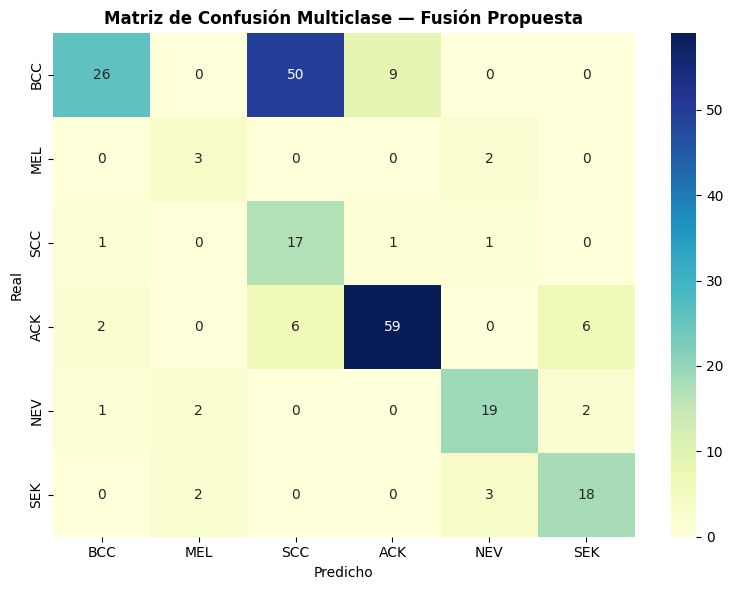


Reporte detallado — Fusión propuesta:
              precision    recall  f1-score   support

         BCC       0.87      0.31      0.45        85
         MEL       0.43      0.60      0.50         5
         SCC       0.23      0.85      0.37        20
         ACK       0.86      0.81      0.83        73
         NEV       0.76      0.79      0.78        24
         SEK       0.69      0.78      0.73        23

    accuracy                           0.62       230
   macro avg       0.64      0.69      0.61       230
weighted avg       0.77      0.62      0.63       230



In [11]:
yt, yp = preds_guardados['Fusión propuesta']
cm = confusion_matrix(yt, yp, labels=range(6))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title('Matriz de Confusión Multiclase — Fusión Propuesta', fontweight='bold')
ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'multiclase_confusion_propuesta.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nReporte detallado — Fusión propuesta:')
print(classification_report(yt, yp, target_names=CLASSES, zero_division=0))